In [ ]:
import pandas as pd

# Load the dataset
file_path = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(file_path)

# Select the school
school_name = "Frederick Douglass Academy III Secondary School"
school_data = df[df["School Name"] == school_name]

# Summarize key performance metrics
school_summary = school_data.groupby(["Regents Exam", "Year"]).agg(
    Mean_Score=("Mean Score", "first"),
    Total_Tested=("Total Tested", "first"),
    Percent_Below_65=("Percent Scoring Below 65", "first"),
    Percent_65_or_Above=("Percent Scoring 65 or Above", "first"),
    Percent_80_or_Above=("Percent Scoring 80 or Above", "first"),
    Percent_CR=("Percent Scoring CR", "first")
).reset_index()

# Display the summary
print(school_summary)



                       Regents Exam  Year Mean_Score  Total_Tested  \
0             Algebra2/Trigonometry  2015       31.8            17   
1               Common Core Algebra  2015       56.6           105   
2               Common Core Algebra  2016       62.1           226   
3               Common Core Algebra  2017       61.1           214   
4              Common Core Algebra2  2017       49.9            19   
5               Common Core English  2015       68.3           101   
6               Common Core English  2016       71.8           101   
7               Common Core English  2017       69.2           122   
8              Common Core Geometry  2015         53            41   
9              Common Core Geometry  2017       58.3            44   
10                          English  2015       65.7            92   
11                          English  2016       53.3            12   
12                         Geometry  2015         55            63   
13                  

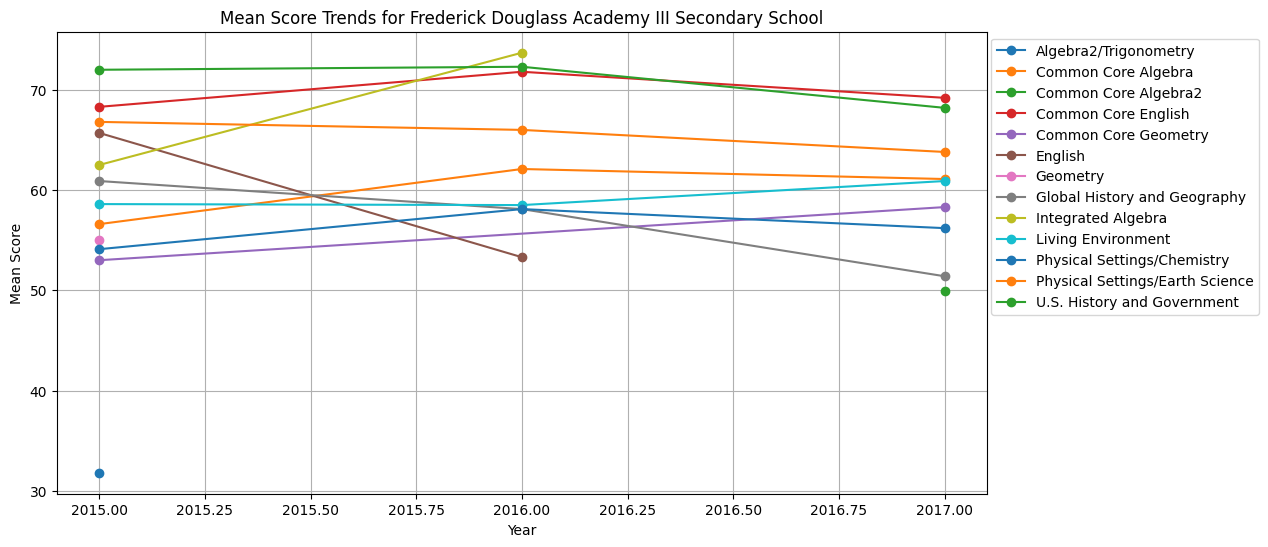

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(file_path)

# Select the school
school_name = "Frederick Douglass Academy III Secondary School"
school_data = df[df["School Name"] == school_name]

# Summarize key performance metrics
school_summary = school_data.groupby(["Regents Exam", "Year"]).agg(
    Mean_Score=("Mean Score", "first"),
    Total_Tested=("Total Tested", "first")
).reset_index()

# Convert Mean Score to numeric, handling non-numeric values
school_summary["Mean_Score"] = pd.to_numeric(school_summary["Mean_Score"], errors="coerce")

# Plot Mean Scores over the years for different exams
plt.figure(figsize=(12, 6))
for exam in school_summary["Regents Exam"].unique():
    exam_data = school_summary[school_summary["Regents Exam"] == exam]
    plt.plot(exam_data["Year"], exam_data["Mean_Score"], marker="o", label=exam)

plt.xlabel("Year")
plt.ylabel("Mean Score")
plt.title(f"Mean Score Trends for {school_name}")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()


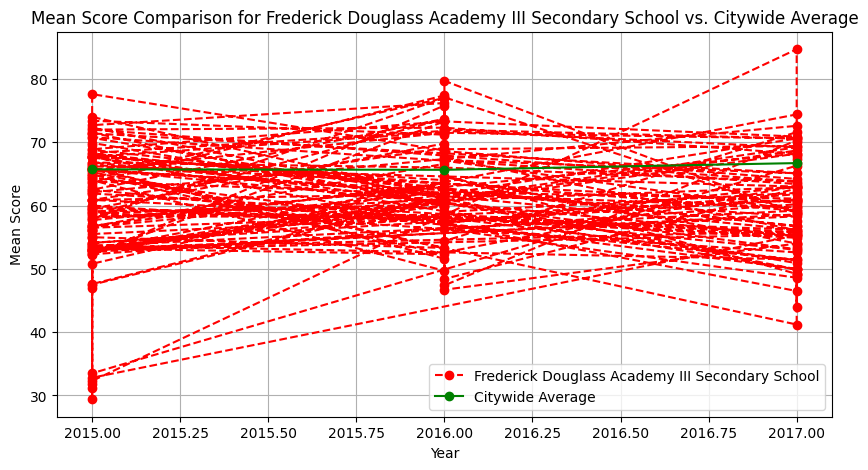

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"  # Update with your file path
df = pd.read_csv(file_path)

# Select the target school
selected_school = "Frederick Douglass Academy III Secondary School"

# Convert Mean Score to numeric and clean data
df["Mean Score"] = pd.to_numeric(df["Mean Score"], errors="coerce")
df_cleaned = df.dropna(subset=["Mean Score"])

# Filter data for the selected school and all schools
school_data = df_cleaned[df_cleaned["School Name"] == selected_school]
all_schools_data = df_cleaned

# Plot comparison
plt.figure(figsize=(10, 5))
if not school_data.empty:
    plt.plot(school_data["Year"], school_data["Mean Score"], 'r--o', label=selected_school)

plt.plot(all_schools_data.groupby("Year")["Mean Score"].mean(), 'g-o', label="Citywide Average")

plt.xlabel("Year")
plt.ylabel("Mean Score")
plt.legend()
plt.title(f"Mean Score Comparison for {selected_school} vs. Citywide Average")
plt.grid(True)
plt.show()
